# Loss Functions

## How close was our guess?

Imagine a greenhouse thermometer will soon report the temperature. Before it does, a model guesses nineteen degrees. The thermometer then reads twenty degrees. Another model guessed twenty-six degrees.

We can see that nineteen was closer. But a computer needs an exact rule for comparing guesses. Should a miss of six degrees count as six small mistakes, or should a large miss receive an even larger penalty?

A **loss function** is that scoring rule. It takes a **prediction**, the model's answer, and a **target**, the answer in our data, and returns a penalty. For the losses in this lesson, smaller means a closer match according to the chosen rule.

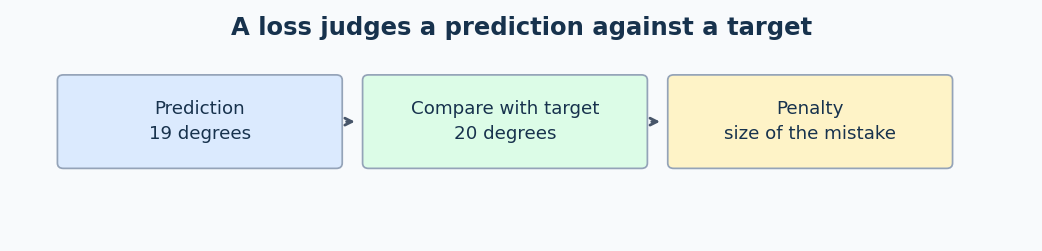

Think of loss as a measuring tool. A ruler measures length; a loss function measures a particular kind of mismatch. Choosing the tool matters because different tools can prefer different predictions.

We will follow temperature guesses into the arithmetic, then ask how the rule changes when the answer is a category. The [code companion](06_Loss_Functions.ipynb) reproduces these small examples in PyTorch. Its predictions are invented so we can inspect every calculation; no model is trained.

## Start with the problem this lesson solves

An ANN can output a prediction before it has learned anything. To improve it, we need a numerical rule for judging a prediction against its target. A **loss function** turns a mistake into a scalar that can guide learning.

The rule matters: being two degrees wrong, missing an urgent positive case, and assigning very low probability to the true class are different kinds of mistakes. A loss makes the chosen preference explicit; it does not by itself update the network.

## Calculate a loss and see the learning direction it creates

**Numeric prediction.** In this small illustrative temperature example, targets are $[20,22]$ and predictions are $[18,25]$. Subtract target from prediction: errors are $[-2,3]$. Their ordinary average is $0.5$, which hides the two substantial misses by cancellation.

Absolute values give $[2,3]$, so mean absolute error is $(2+3)/2=2.5$ degrees. Squares give $[4,9]$, so mean squared error is $(4+9)/2=6.5$ squared degrees. The three-degree miss contributes nine rather than three, making large errors count more strongly.

For MSE on $N$ predictions, the derivative with respect to prediction $i$ is $2(\hat y_i-y_i)/N$. With $N=2$, the gradients are $[-2,3]$. Reducing loss calls for increasing the first prediction and decreasing the second. If predictions themselves were independently adjustable parameters, an SGD rate of $0.1$ would change them to $[18.2,24.7]$. New errors are $[-1.8,2.7]$ and new MSE is $(3.24+7.29)/2=5.265$. In an ANN, predictions are not independent parameters: the chain rule carries these signals back into shared weights.

**Binary classification.** If the true label is one and the model assigns it probability $p=0.8$, binary cross-entropy is $-\ln(0.8)\approx0.223144$. Assigning $p=0.2$ gives $-\ln(0.2)\approx1.609438$. The natural logarithm makes confident wrong answers expensive. For a zero target, use $-\ln(1-p)$ instead.

**Three competing classes.** Let logits be $[2,1,0]$ and the true class be the first. Exponentiate: $[e^2,e^1,e^0]\approx[7.389056,2.718282,1]$. Their sum is $11.107338$. Divide each by the sum to get probabilities approximately $[0.665241,0.244728,0.090031]$. Loss is $-\ln(0.665241)\approx0.407606$.

For softmax cross-entropy on this one example, logit gradients equal probabilities minus the one-hot target: approximately $[-0.334759,0.244728,0.090031]$. An update therefore tends to raise the true class's logit and lower the others. The network learns which weights can produce those changes.

## Why loss is more informative than a right-or-wrong count

Accuracy only changes when a decision crosses a boundary. Cross-entropy can improve when probability on the true class rises from 0.6 to 0.8, even though both answers count as correct. This gives learning a more informative signal.

Choose the loss according to the prediction's meaning. MSE is natural for many numeric targets; binary and multiclass cross-entropy correspond to different label structures. Keep predictions and targets aligned, and check whether a reduction sums or averages. A small training loss is evidence of fitting training examples, not proof of good predictions on new ones.

## First find the mistake, including its direction

Call the true temperature $y$ and the prediction $\hat y$. The little hat above $y$ means “our estimate of this value.” Define the **signed error** as:

$$e=\hat y-y.$$

The letter $e$ names the error. Subtracting the target tells us both how far away the guess is and which side it falls on.

| Target | Prediction | Calculation | Meaning |
| --- | --- | --- | --- |
| 20 | 18 | $18-20=-2$ | Two degrees too low |
| 20 | 22 | $22-20=+2$ | Two degrees too high |
| 20 | 20 | $20-20=0$ | Exactly right |

It is tempting to average signed errors. But the first two errors would cancel: $(-2+2)/2=0$. That sounds like perfection even though both guesses missed.

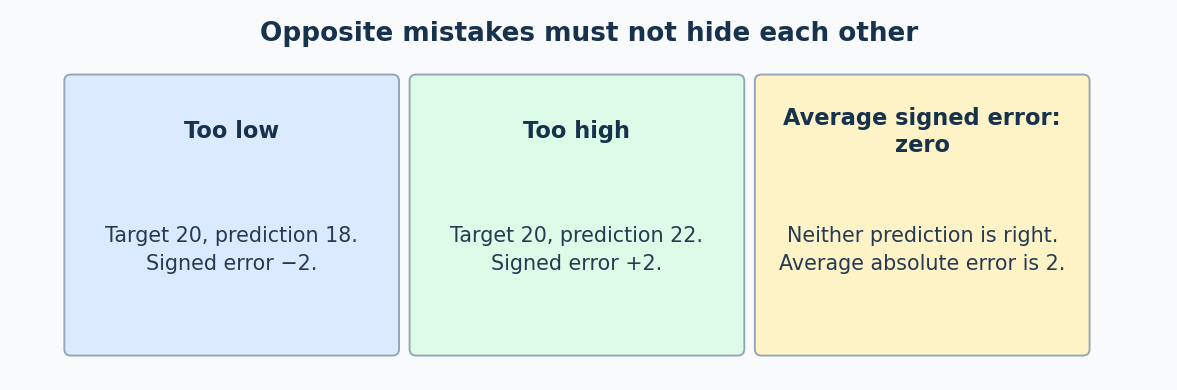

The average signed error can reveal a tendency to overpredict or underpredict. It cannot, by itself, tell us how close the guesses are. To measure closeness, we turn each mistake into a nonnegative penalty **before** averaging.

## Measure the size of each miss

An **absolute value** keeps a number's distance from zero and removes its sign. We write it with vertical bars: $|-3|=3$ and $|2|=2$.

Here are three temperature guesses we will reuse:

| Greenhouse | Target $y$ | Prediction $\hat y$ | Signed error $e$ | Absolute error $|e|$ | Squared error $e^2$ |
| --- | --- | --- | --- | --- | --- |
| A | 20 | 19 | -1 | 1 | 1 |
| B | 22 | 24 | 2 | 2 | 4 |
| C | 24 | 21 | -3 | 3 | 9 |

**Mean absolute error**, or **MAE**, adds the absolute errors and divides by how many there are. “Mean” is another word for average.

$$\mathrm{MAE}=\frac{1+2+3}{3}=2\text{ degrees}.$$

We can read that answer aloud: the predictions miss by two degrees on average. This does not mean every prediction misses by two degrees; their distances are one, two, and three.

For any number of examples, the same recipe is

$$\mathrm{MAE}=\frac{1}{N}\sum_{i=1}^{N}|\hat y_i-y_i|.$$

Here $N$ is the number of examples, $i$ picks one example, and $\sum$ means “add these terms.” The formula is simply the table calculation written so it works for a table of any length.

## Make large misses count more strongly

Another way to remove the sign is to **square** the error: multiply it by itself. Both $3\times3$ and $(-3)\times(-3)$ give nine.

**Mean squared error**, or **MSE**, averages those squared penalties:

$$\mathrm{MSE}=\frac{1}{N}\sum_{i=1}^{N}(\hat y_i-y_i)^2
=\frac{1+4+9}{3}=\frac{14}{3}\approx4.667.$$

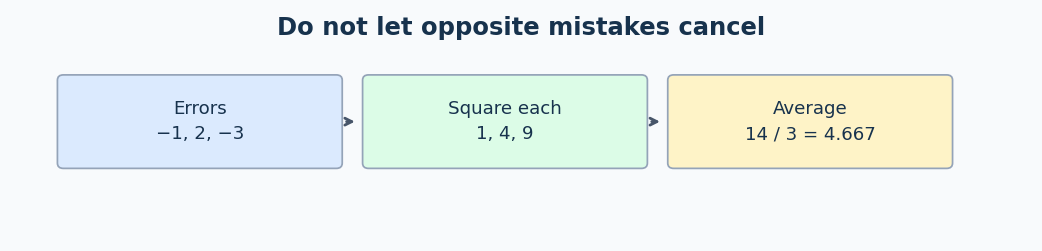

Notice what happened to the largest miss. It contributed three to the absolute-error total but nine to the squared-error total. Doubling a miss doubles its absolute penalty and quadruples its squared penalty.

Because we squared temperatures, MSE has units of **squared degrees**. That is useful for the scoring rule but awkward to describe to someone caring for the greenhouse. **Root mean squared error**, or **RMSE**, takes the square root at the end:

$$\mathrm{RMSE}=\sqrt{14/3}\approx2.160\text{ degrees}.$$

The square root is the nonnegative number that, multiplied by itself, gives MSE. It restores the original units. RMSE is not the same as MAE: we still squared the individual misses first.

| Measure | What happens to each error? | What happens at the end? | Result here |
| --- | --- | --- | --- |
| MAE | Take its absolute value | Average | 2 degrees |
| MSE | Square it | Average | About 4.667 squared degrees |
| RMSE | Square it | Average, then take a square root | About 2.160 degrees |

For the same examples and targets, MSE and RMSE rank predictions in the same order because square root preserves order. Their numerical values and units differ.

## The scoring rule can change the preferred answer

Suppose the recorded temperatures are $20,20,32$. We will compare two deliberately simple models: one always guesses twenty, and one always guesses twenty-four.

| Constant guess | Absolute errors | MAE | Squared errors | MSE |
| --- | --- | --- | --- | --- |
| 20 | 0, 0, 12 | $12/3=4$ | 0, 0, 144 | $144/3=48$ |
| 24 | 4, 4, 8 | $16/3\approx5.333$ | 16, 16, 64 | $96/3=32$ |

MAE prefers twenty. MSE prefers twenty-four. The squared rule rewards reducing the biggest miss enough to accept two new, smaller misses.

For a constant guess, a **median** minimizes MAE: a middle value after sorting the targets. Their **mean** minimizes MSE: here $(20+20+32)/3=24$. We are describing the best constant under each rule, not claiming that a useful model must make constant predictions.

A reading far from the others is often called an **outlier**. It might be a broken sensor, or it might be a real hot greenhouse that matters greatly. The loss cannot tell which story is true. Investigating the data and deciding which mistakes matter remain part of the task.

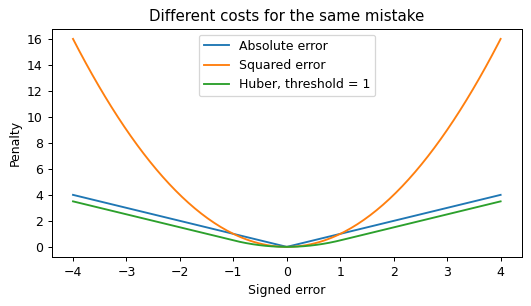

In this plot, horizontal position is the signed error and height is its penalty. All curves are lowest at zero. The squared curve rises fastest far from zero, showing why a large miss can have such a strong influence.

## A middle choice for small and large mistakes

The third curve is **Huber loss**. Near the correct answer, it uses half the squared error. Farther away, it grows in a straight line. This keeps a smooth rounded center without the rapidly growing squared penalty for very large misses.

A threshold named $\delta$ (the Greek letter “delta”) chooses where the rule changes. It is positive and uses the same units as the error. With $\delta=1$, the recipe is:

| Size of error | Rule | Example |
| --- | --- | --- |
| $|e|\leq1$ | $e^2/2$ | Error 0.5 gives $0.25/2=0.125$ |
| $|e|>1$ | $|e|-0.5$ | Error 3 gives $3-0.5=2.5$ |

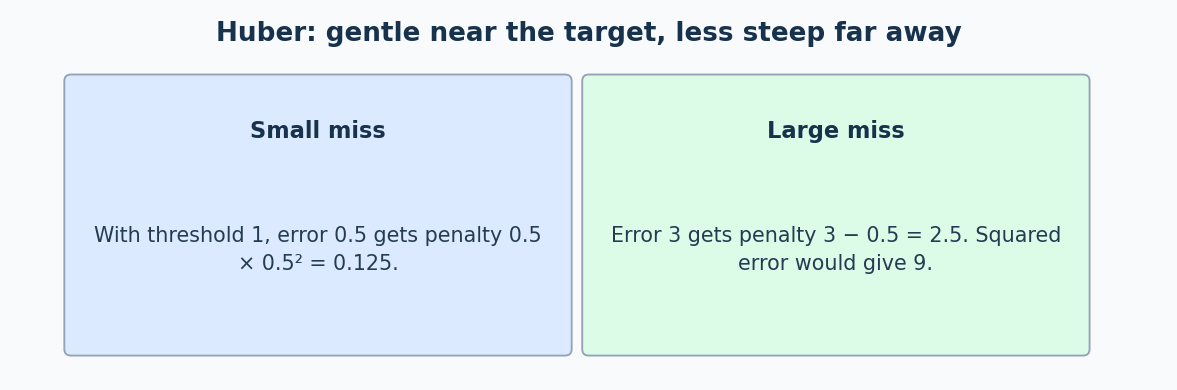

For a different threshold, the outer rule becomes $\delta(|e|-\delta/2)$ and the inner rule stays $e^2/2$. At the boundary both rules give $\delta^2/2$, so there is no jump in the penalty.

Huber is useful when we want large errors to have less influence than they would under MSE. It does not erase those examples or prove they are wrong. Its threshold must also make sense for the units and size of the target values.

## What if the answer is yes or no?

Temperature prediction is **regression**: the answer is a numerical amount. Now change the question to “Does this greenhouse need attention?” This is **binary classification**: choosing between two categories.

Let the target be $y=1$ for “needs attention” and $y=0$ for “does not.” The model gives a probability $p$ for “needs attention.” A probability of $0.9$ means the model assigns ninety percent probability to that outcome; the other outcome receives $1-p=0.1$.

We want to reward probability placed on the outcome that actually happened. Call that probability $q$:

| Observed target | Probability assigned to the observed outcome |
| --- | --- |
| Needs attention, $y=1$ | $q=p$ |
| Does not need attention, $y=0$ | $q=1-p$ |

The penalty is $-\log q$. Here $\log$ is the **natural logarithm**. You do not need to calculate logarithms by hand to understand the rule: $\log 1=0$, and for probabilities between zero and one the log is negative. The minus sign makes the penalty positive. As the probability of the observed outcome falls toward zero, the penalty grows without bound.

| Probability of the observed outcome $q$ | Penalty $-\log q$ | Interpretation |
| --- | --- | --- |
| 0.9 | About 0.105 | Much probability went to what happened |
| 0.6 | About 0.511 | Some uncertainty remained |
| 0.1 | About 2.303 | The model strongly favored the wrong outcome |

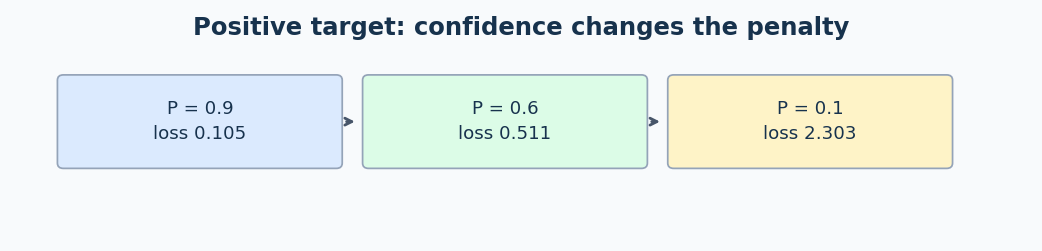

Why use this rule? It rewards the model for assigning probability to the observed outcomes and strongly penalizes confidently wrong guesses. Across representative examples, it encourages probabilities that reflect how often outcomes occur; it does not guarantee that a particular trained model achieves that goal.

## Put both possible answers into one formula

The rule just described is **binary cross-entropy**, often shortened to **BCE**. “Binary” refers to the two outcomes. In this setting, “cross-entropy” names the logarithmic penalty for the probability assigned to the observed answer.

$$L(y,p)=-[y\log p+(1-y)\log(1-p)].$$

$L$ names the loss. The target $y$ acts like a switch: for a positive target it keeps the first term; for a negative target it keeps the second.

| Target | Surviving calculation | With $p=0.9$ |
| --- | --- | --- |
| $y=1$ | $-\log p$ | $-\log0.9\approx0.105$ |
| $y=0$ | $-\log(1-p)$ | $-\log0.1\approx2.303$ |

The same prediction receives different penalties because the target changed. A high probability of attention is helpful when attention is needed and costly when it is not.

These formulas describe probabilities strictly between zero and one. At the endpoints, we interpret the loss by limits: assigning probability one to the observed answer gives zero; assigning zero gives an unbounded penalty. In code, directly evaluating logs at rounded endpoints can cause numerical problems. That is why the form of the model's output matters.

## Let PyTorch handle the probability calculation safely

A model can output a **logit**, a raw score that may be negative, zero, or positive. For binary classification, the **sigmoid** function turns that score $z$ into a probability:

$$p=\frac{1}{1+\exp(-z)}.$$

The function $\exp(a)$ means the mathematical constant $e\approx2.718$ raised to power $a$; here that constant is not our earlier error symbol. A score of zero gives probability one-half. Large positive scores give probabilities near one; large negative scores give probabilities near zero.

Computers store numbers with limited precision. For an extreme score, a separately calculated probability may round to exactly zero or one. Taking its logarithm afterward can then fail to represent the intended finite loss.

PyTorch's `BCEWithLogitsLoss` accepts the raw score and combines the probability and loss calculations in a stable way.

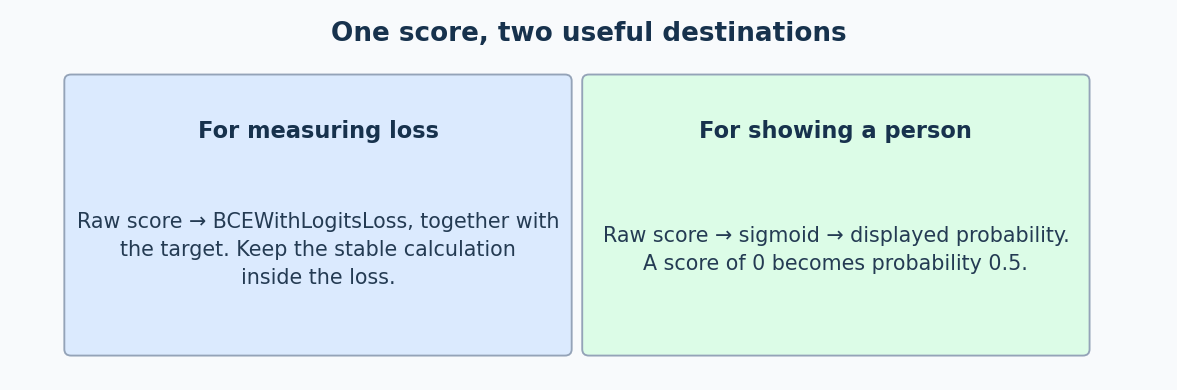

The code companion also checks its stable mathematical form:

$$L(z,y)=\max(z,0)-zy+\log(1+\exp(-|z|)).$$

Here $\max(z,0)$ keeps whichever is larger, $zy$ means multiplication, and $|z|$ is the magnitude of the score. The exponent $-|z|$ is never positive, which avoids trying to represent an enormous exponential. `log1p(a)` evaluates $\log(1+a)$ accurately even when $a$ is small.

For example, a raw score of $1000$ with target zero is confidently wrong and gives a loss of approximately $1000$, a large but finite number. The companion verifies this without needing to form the rounded probability first.

**Pass raw logits directly to `BCEWithLogitsLoss`.** Applying sigmoid first would make the function treat probabilities as fresh raw scores and calculate a different loss. Use sigmoid separately when you want to display probabilities to a reader.

## Choose one answer from several categories

Suppose our labels are now “normal,” “too dry,” and “too hot.” For this example, assume the labeling rule assigns **exactly one** category to each greenhouse.

The model supplies a raw score for each category. **Softmax** converts the scores into probabilities that compete for a total of one: exponentiate each score, then divide by the sum of all those exponentials.

For scores $(2,1,0)$, the exponentials are approximately $(7.389,2.718,1)$ and their sum is $11.107$. Dividing gives:

| Category | Raw score | Probability |
| --- | --- | --- |
| Normal | 2 | $7.389/11.107\approx0.665$ |
| Too dry | 1 | $2.718/11.107\approx0.245$ |
| Too hot | 0 | $1/11.107\approx0.090$ |

We reuse the same idea as before: take minus the log probability of the observed class. If the target is normal, the loss is $-\log0.665\approx0.408$. If it is too hot, the loss is $-\log0.090\approx2.408$.

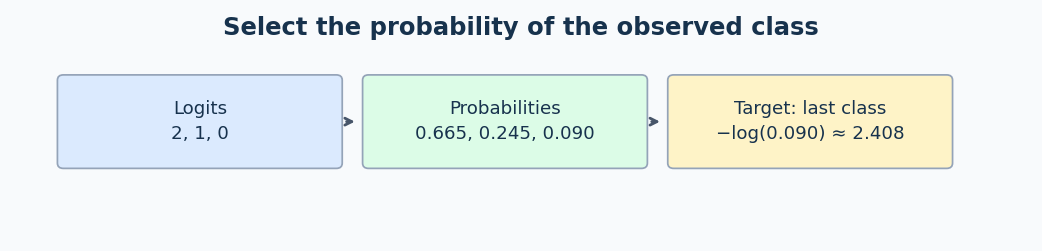

PyTorch's `CrossEntropyLoss` takes **raw logits**, performing the stable log-probability calculation internally. Do not apply softmax first. Softmax is useful separately for displaying the probabilities, just as sigmoid was in the binary case.

Real greenhouses can be too dry and too hot at the same time. If the task allows both labels, making them compete for exactly one answer would misrepresent the problem. Separate yes-or-no outputs, each with binary cross-entropy, are a common choice for that **multilabel** situation.

## Keep each prediction paired with its own target

A correct loss also needs correctly arranged data. A **batch** is a group of examples processed together. A tensor's **shape** describes the lengths of its axes, such as rows and columns.

| Task in the companion | Prediction shape and contents | Target shape and contents | PyTorch loss |
| --- | --- | --- | --- |
| One temperature per example | `(B, 1)`, floating-point values | `(B, 1)`, floating-point temperatures | `L1Loss`, `MSELoss`, or `HuberLoss` |
| One yes-or-no outcome | `(B, 1)`, raw logits | `(B, 1)`, floating-point zeros or ones | `BCEWithLogitsLoss` |
| One class from several | `(B, C)`, raw logits | `(B,)`, integer class indices | `CrossEntropyLoss` |

$B$ means batch size and $C$ means class count. Floating-point storage allows fractional values. In our multiclass setup, `torch.long` stores integer class indices: normal is zero, too dry is one, and too hot is two. An index is a position in the class list, not a measurement of how severe a condition is.

Why be so careful about shapes? Subtracting temperature targets shaped `(3,)` from predictions shaped `(3, 1)` produces a `(3, 3)` table through **broadcasting**, which automatically expands compatible axes. It compares every prediction with every target instead of pairing matching examples.

| Intended comparison | Accidental expanded comparison |
| --- | --- |
| Prediction A with target A | Prediction A with targets A, B, and C |
| Prediction B with target B | Prediction B with targets A, B, and C |
| Prediction C with target C | Prediction C with targets A, B, and C |

The computer can complete that calculation, but it answers the wrong question. Matching regression shapes protects the intended pairing. Classification shapes follow their own rules in the table because each row of class scores belongs to one class-index target.

## Decide how to combine individual penalties

So far, we have usually averaged. Libraries call the choice of how to combine penalties a **reduction**. It means reducing a collection of numbers to a summary, or leaving the collection untouched.

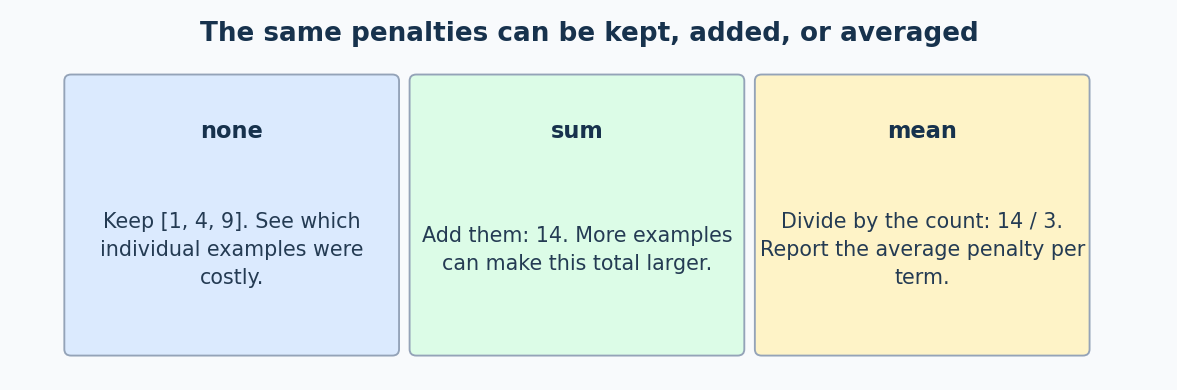

In PyTorch, choose `reduction="none"`, `"sum"`, or `"mean"`. Keeping individual penalties helps locate difficult examples. A sum measures the total penalty. A mean makes comparisons less dependent on how many terms were included.

If we duplicate all three penalties, the sum doubles from fourteen to twenty-eight. The mean stays $14/3$. The predictions did not improve or worsen; only the number of entries changed.

There is one more averaging trap. Suppose the first batch contains penalties $1,4$ and the second contains just $9$:

| Batch | Penalties | Count | Batch mean |
| --- | --- | --- | --- |
| A | 1, 4 | 2 | 2.5 |
| B | 9 | 1 | 9 |

Averaging the two batch means gives $(2.5+9)/2=5.75$. That gives the lone example in batch B as much influence as both examples in batch A together.

To recover the overall example average, multiply each batch mean by its count, add, then divide by the total count:

$$\frac{2.5\times2+9\times1}{2+1}=\frac{14}{3}\approx4.667.$$

In these examples, MSE and binary cross-entropy average output elements; unweighted class-index cross-entropy averages examples. These counts coincide when there is one scalar output per example, but not always with multiple outputs. Class weights or ignored targets can also change the averaging rule, so the denominator must match the loss being used.

## A correct decision and a good probability are different things

**Accuracy** is the fraction of examples whose chosen category is correct. For this binary demonstration, choose “needs attention” whenever its probability is above one-half.

Consider two examples whose targets are attention and no attention:

| Model | Probability of attention for the positive example | Probability of attention for the negative example | Accuracy | Mean BCE |
| --- | --- | --- | --- | --- |
| Tentative | 0.6 | 0.4 | 100% | About 0.511 |
| Confident | 0.9 | 0.1 | 100% | About 0.105 |

Both models choose the correct categories. The confident model assigns more probability to the true outcome in each case, so its cross-entropy is lower.

This does not mean confidence is always good. If the confident model is wrong, its penalty can be much larger. Good confidence should match reality over many examples. A model is **calibrated** when predictions assigned about ninety percent confidence are correct about ninety percent of the time, across suitable groups of examples. A low loss on a few examples does not prove calibration.

Accuracy also hides which examples were missed. If almost every greenhouse is normal, always predicting normal can look accurate while missing the rare cases that need help. Examine those cases separately. Giving some classes more weight in the loss changes their influence, and should reflect the actual purpose of the model.

## Read the score in the context of the task

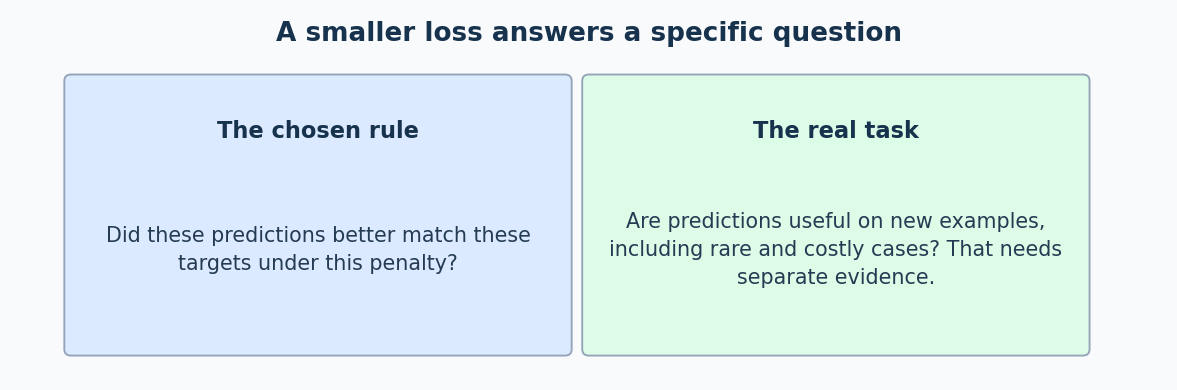

A loss number becomes useful when we know what was predicted, which targets were used, how mistakes were penalized, and how the penalties were combined.

| Tempting conclusion | What the number actually tells us |
| --- | --- |
| “The smaller printed number is always the better model.” | Only comparable rules, units, data, and reductions support that comparison. |
| “Small training loss proves the model works.” | Training loss measures fit to examples used for learning. Held-out examples, kept out of training, provide evidence about new-data performance. |
| “The target must be correct.” | Targets can contain measurement errors or unsuitable labels. Loss measures agreement with them, not their truth. |
| “Calculating loss teaches the model.” | Calculating loss produces a score. It does not itself change the model's parameters. |

Units alone can change the scale dramatically. If a regression target and its prediction are both multiplied by ten, each error is multiplied by ten, MAE by ten, and MSE by a hundred. Nothing about the underlying predictive quality necessarily changed.

For a temperature task, MAE provides an easy-to-read average miss, while MSE places more emphasis on large misses. For category probabilities, cross-entropy judges the probability given to the observed answer. The appropriate choice comes from what the answer means and which mistakes the task needs to discourage.

The companion uses fixed predictions to make these distinctions visible. Its printed losses demonstrate the scoring rules; they are not evidence of a trained model's performance on new greenhouses.

## Hinge, KL, and categorical target formats

Hinge loss for a binary target $y\in\{-1,+1\}$ and raw score $s$ is $\max(0,1-ys)$: the correct class must have a margin of one. KL divergence compares target distribution $P$ with predicted distribution $Q$ using $D_{KL}(P\Vert Q)=\sum_jP_j\log(P_j/Q_j)$. It is directional, and `kl_div` expects `log Q` followed by `P`.

Categorical cross-entropy accepts integer class indices of shape `(batch,)` or one-hot/soft targets of shape `(batch, classes)`. For a one-hot target, only the selected negative log probability remains, so both encodings agree. Index targets are compact; one-hot or soft distributions are useful when targets express uncertainty.